> **NOTE (2026-04-08):** The variance-decomposition math used in the paper is now consolidated in `src/variance_analysis.py` with reviewer-defensible nested ω² + mixed-effects ICC + cluster bootstrap + subject-level PERMANOVA. The headline numbers are produced by `scripts/run_variance_analysis.py` (run under `stats_env`) and dumped to `paper/figures/variance_analysis.json`. The cells below are kept for exploration but their `eta_squared` definitions are superseded — see `docs/eta_squared_pipeline_explanation.md`.

# FM Representation Diagnostic Analysis

**Goal**: Understand *why* EEG foundation models fail at cross-subject stress classification.

All 3 FMs (LaBraM, CBraMod, REVE) achieve near-chance BA (~49-55%) on subject-level CV,
yet LaBraM reaches 86% on trial-level CV. This notebook diagnoses whether FM representations
encode subject identity rather than stress pathology.

**Analyses**:
1. t-SNE visualization (subject ID vs stress label)
2. Variance decomposition (subject vs stress)
3. Effect size comparison (FM features vs classical band power)
4. Within-subject vs between-subject similarity
5. Silhouette analysis

In [1]:
import os, sys, pickle, warnings
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy import stats
from itertools import combinations

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Project root
os.chdir('/raid/jupyter-linjimmy1003.md10/UCSD_stress')
sys.path.insert(0, '.')

# Register extractors
import baseline.reve      # noqa: F401
import baseline.labram    # noqa: F401
import baseline.cbramod   # noqa: F401
from baseline.abstract import create_extractor
from pipeline.dataset import StressEEGDataset, stress_collate_fn
from src.model import DecoupledStressModel

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

SAVE_DIR = 'results/fm_diagnosis'
os.makedirs(SAVE_DIR, exist_ok=True)

DEVICE = 'cuda:5'  # change as needed
CSV_PATH = 'data/comprehensive_labels_stress.csv'
DATA_ROOT = 'data'
MAX_DURATION = 400

FM_CONFIGS = {
    'LaBraM':  {'extractor': 'labram',  'norm': 'zscore'},
    'CBraMod': {'extractor': 'cbramod', 'norm': 'zscore'},
    'REVE':    {'extractor': 'reve',    'norm': 'none'},
}

print(f'Device: {DEVICE}')
print(f'Save dir: {SAVE_DIR}')

/raid/jupyter-linjimmy1003.md10/.conda/envs/timm_eeg/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/raid/jupyter-linjimmy1003.md10/.conda/envs/timm_eeg/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by as

Device: cuda:5
Save dir: results/fm_diagnosis


## 1. Feature Extraction
Extract frozen FM embeddings for all 82 recordings. Cached to `.npz` after first run.

In [2]:
def extract_all_features(model, dataset, device):
    """Extract pooled embeddings for all recordings (frozen backbone)."""
    model.eval()
    loader = DataLoader(dataset, batch_size=4, shuffle=False,
                        collate_fn=stress_collate_fn, num_workers=0)
    all_feats = []
    with torch.no_grad():
        for epochs_batch, _labels, _scores, mask, _pids in loader:
            epochs_batch = epochs_batch.to(device)
            mask = mask.to(device)
            with torch.autocast('cuda', dtype=torch.bfloat16):
                pooled = model.extract_pooled(epochs_batch, mask)
            all_feats.append(pooled.float().cpu().numpy())
    return np.concatenate(all_feats, axis=0)


# Load dataset once to get metadata
# Use zscore norm for metadata extraction (norm doesn't affect labels/IDs)
meta_ds = StressEEGDataset(CSV_PATH, DATA_ROOT, norm='zscore', max_duration=MAX_DURATION)
patient_ids = meta_ds.get_patient_ids()
labels = meta_ds.get_labels()
stress_scores = np.array([r['stress_score'] for r in meta_ds.records])
n_recs = len(meta_ds)
print(f'\nDataset: {n_recs} recordings, {len(np.unique(patient_ids))} subjects')
print(f'Labels: {(labels==0).sum()} normal, {(labels==1).sum()} increase')

# Extract features for each FM
fm_features = {}
for fm_name, cfg in FM_CONFIGS.items():
    cache_path = os.path.join(SAVE_DIR, f'features_{fm_name.lower()}.npz')
    
    if os.path.isfile(cache_path):
        data = np.load(cache_path)
        fm_features[fm_name] = data['features']
        print(f'{fm_name}: loaded from cache, shape={fm_features[fm_name].shape}')
        continue
    
    print(f'\n--- Extracting {fm_name} features ---')
    ds = StressEEGDataset(CSV_PATH, DATA_ROOT, norm=cfg['norm'], max_duration=MAX_DURATION)
    extractor = create_extractor(cfg['extractor'])
    model = DecoupledStressModel(extractor, embed_dim=extractor.embed_dim)
    model.freeze_backbone()
    model = model.to(DEVICE)
    
    feats = extract_all_features(model, ds, DEVICE)
    fm_features[fm_name] = feats
    np.savez_compressed(cache_path, features=feats)
    print(f'{fm_name}: extracted shape={feats.shape}, saved to {cache_path}')
    
    # Free GPU memory
    del model, extractor, ds
    torch.cuda.empty_cache()

print('\nAll FM features ready:')
for name, feats in fm_features.items():
    print(f'  {name}: {feats.shape}')

Duration filter: skipped 10 recordings > 400s
Dataset: 82 recordings loaded (19 increase, 63 normal)
Cache: preprocessed 21 new recordings → data/cache
Cache: 82 recordings ready (61 cached, 21 new)

Dataset: 82 recordings, 17 subjects
Labels: 63 normal, 19 increase

--- Extracting LaBraM features ---
Duration filter: skipped 10 recordings > 400s
Dataset: 82 recordings loaded (19 increase, 63 normal)
Cache: 82 recordings ready (82 cached, 0 new)
[LaBraM] Loaded 221/223 params from weights/labram-base/model.safetensors
[LaBraM] Missing: ['fc_norm.weight', 'fc_norm.bias']
LaBraM: extracted shape=(82, 200), saved to results/fm_diagnosis/features_labram.npz

--- Extracting CBraMod features ---
Duration filter: skipped 10 recordings > 400s
Dataset: 82 recordings loaded (19 increase, 63 normal)
Cache: 82 recordings ready (82 cached, 0 new)
[CBraMod] Loaded 209/209 params from weights/cbramod-base/pretrained_weights.pth
CBraMod: extracted shape=(82, 200), saved to results/fm_diagnosis/feature

## 2. t-SNE Visualization: Subject ID vs Stress Label
If features cluster by subject but not by stress, FMs encode identity rather than pathology.

Saved: results/fm_diagnosis/tsne_subject_vs_stress.png


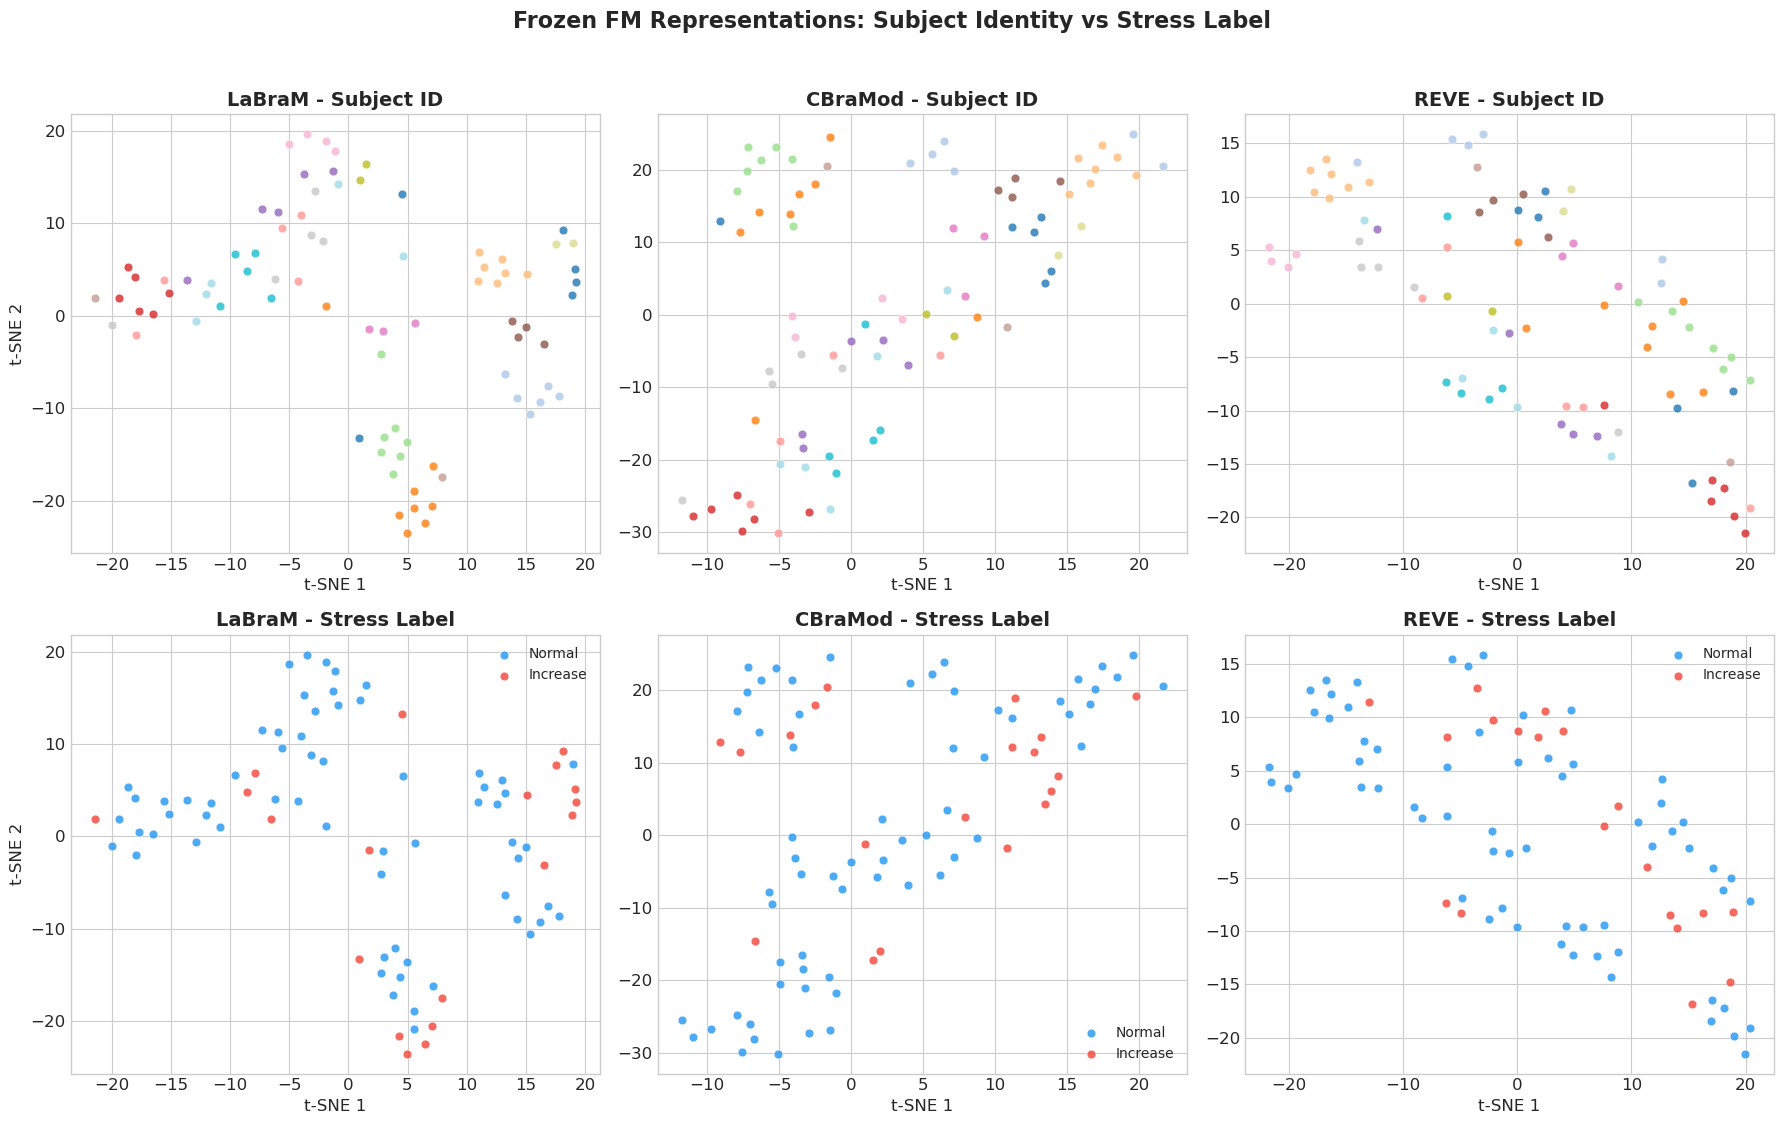

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

unique_subjects = np.unique(patient_ids)
cmap_subj = plt.cm.tab20(np.linspace(0, 1, len(unique_subjects)))
subj_color_map = {s: cmap_subj[i] for i, s in enumerate(unique_subjects)}
label_colors = {0: '#2196F3', 1: '#F44336'}  # blue=normal, red=increase
label_names = {0: 'Normal', 1: 'Increase'}

tsne_embeddings = {}

for col, (fm_name, feats) in enumerate(fm_features.items()):
    # t-SNE
    tsne = TSNE(n_components=2, perplexity=min(10, len(feats)-1),
                random_state=42, init='pca', learning_rate='auto')
    emb = tsne.fit_transform(feats)
    tsne_embeddings[fm_name] = emb
    
    # Top row: colored by subject ID
    ax = axes[0, col]
    for sid in unique_subjects:
        mask = patient_ids == sid
        ax.scatter(emb[mask, 0], emb[mask, 1], c=[subj_color_map[sid]],
                   s=40, alpha=0.8, edgecolors='white', linewidth=0.5)
    ax.set_title(f'{fm_name} - Subject ID', fontsize=14, fontweight='bold')
    ax.set_xlabel('t-SNE 1')
    if col == 0:
        ax.set_ylabel('t-SNE 2')
    
    # Bottom row: colored by stress label
    ax = axes[1, col]
    for lab in [0, 1]:
        mask = labels == lab
        ax.scatter(emb[mask, 0], emb[mask, 1], c=label_colors[lab],
                   s=40, alpha=0.8, edgecolors='white', linewidth=0.5,
                   label=label_names[lab])
    ax.set_title(f'{fm_name} - Stress Label', fontsize=14, fontweight='bold')
    ax.set_xlabel('t-SNE 1')
    if col == 0:
        ax.set_ylabel('t-SNE 2')
    ax.legend(loc='best', fontsize=10)

fig.suptitle('Frozen FM Representations: Subject Identity vs Stress Label',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
save_path = os.path.join(SAVE_DIR, 'tsne_subject_vs_stress.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

## 3. Variance Decomposition: Subject vs Stress
How much of the feature variance is explained by subject identity vs stress label?

LaBraM:
  Subject ID  eta^2: 0.6803 +/- 0.1035
  Stress label eta^2: 0.0201 +/- 0.0255
  Ratio (subject/stress): 33.9x

CBraMod:
  Subject ID  eta^2: 0.6258 +/- 0.1256
  Stress label eta^2: 0.0174 +/- 0.0234
  Ratio (subject/stress): 35.9x

REVE:
  Subject ID  eta^2: 0.5462 +/- 0.1168
  Stress label eta^2: 0.0149 +/- 0.0207
  Ratio (subject/stress): 36.6x


Saved: results/fm_diagnosis/variance_decomposition.png


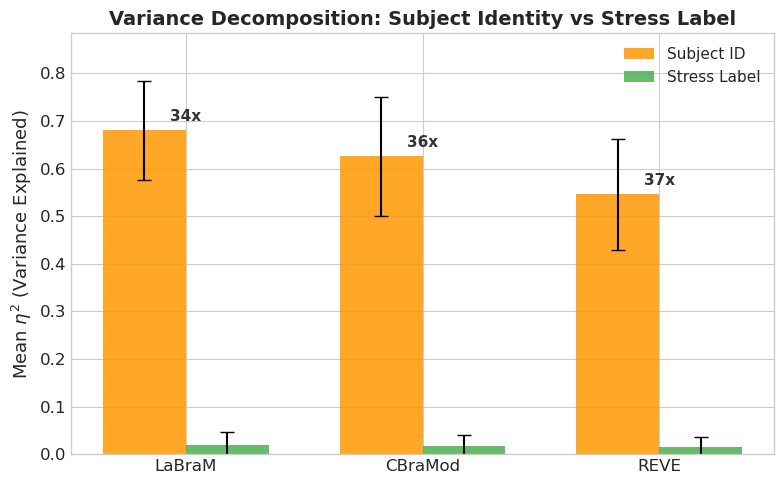

In [4]:
def eta_squared(features, grouping):
    """Compute eta-squared (% variance explained) per feature dim, then average.
    
    eta^2 = SS_between / SS_total for one-way ANOVA.
    """
    groups = np.unique(grouping)
    n_features = features.shape[1]
    eta2_per_dim = []
    
    for d in range(n_features):
        x = features[:, d]
        grand_mean = x.mean()
        ss_total = np.sum((x - grand_mean) ** 2)
        if ss_total < 1e-10:
            eta2_per_dim.append(0.0)
            continue
        ss_between = sum(
            np.sum(grouping == g) * (x[grouping == g].mean() - grand_mean) ** 2
            for g in groups
        )
        eta2_per_dim.append(ss_between / ss_total)
    
    return np.array(eta2_per_dim)


# Compute for each FM
variance_results = {}

for fm_name, feats in fm_features.items():
    eta2_subject = eta_squared(feats, patient_ids)
    eta2_stress = eta_squared(feats, labels)
    
    variance_results[fm_name] = {
        'eta2_subject_mean': eta2_subject.mean(),
        'eta2_subject_std': eta2_subject.std(),
        'eta2_stress_mean': eta2_stress.mean(),
        'eta2_stress_std': eta2_stress.std(),
        'ratio': eta2_subject.mean() / max(eta2_stress.mean(), 1e-10),
    }
    print(f'{fm_name}:')
    print(f'  Subject ID  eta^2: {eta2_subject.mean():.4f} +/- {eta2_subject.std():.4f}')
    print(f'  Stress label eta^2: {eta2_stress.mean():.4f} +/- {eta2_stress.std():.4f}')
    print(f'  Ratio (subject/stress): {variance_results[fm_name]["ratio"]:.1f}x')
    print()

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
fm_names = list(variance_results.keys())
x = np.arange(len(fm_names))
width = 0.35

subj_means = [variance_results[n]['eta2_subject_mean'] for n in fm_names]
subj_stds = [variance_results[n]['eta2_subject_std'] for n in fm_names]
stress_means = [variance_results[n]['eta2_stress_mean'] for n in fm_names]
stress_stds = [variance_results[n]['eta2_stress_std'] for n in fm_names]

bars1 = ax.bar(x - width/2, subj_means, width, yerr=subj_stds,
               label='Subject ID', color='#FF9800', alpha=0.85, capsize=5)
bars2 = ax.bar(x + width/2, stress_means, width, yerr=stress_stds,
               label='Stress Label', color='#4CAF50', alpha=0.85, capsize=5)

# Add ratio annotations
for i, name in enumerate(fm_names):
    ratio = variance_results[name]['ratio']
    ax.annotate(f'{ratio:.0f}x', xy=(x[i], max(subj_means[i], stress_means[i]) + 0.02),
                ha='center', fontsize=11, fontweight='bold', color='#333')

ax.set_ylabel('Mean $\\eta^2$ (Variance Explained)', fontsize=13)
ax.set_title('Variance Decomposition: Subject Identity vs Stress Label', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(fm_names, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, max(subj_means) * 1.3)

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, 'variance_decomposition.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'\nSaved: {save_path}')
plt.show()

## 4. Effect Size: FM Features vs Classical Band Power
Cohen's d between normal vs increase groups on FM features (LDA projection to 1D)
and classical theta/alpha/beta band power.

LaBraM (LDA proj): Cohen's d = 5.150
CBraMod (LDA proj): Cohen's d = 5.210
REVE (LDA proj): Cohen's d = 2.939

--- Computing classical band power features ---
Duration filter: skipped 10 recordings > 400s
Dataset: 82 recordings loaded (19 increase, 63 normal)
Cache: 82 recordings ready (82 cached, 0 new)
Theta band power: Cohen's d = 1.144
Alpha band power: Cohen's d = 0.371
Beta band power: Cohen's d = 0.216
Theta/Alpha Ratio: Cohen's d = 0.013

Saved: results/fm_diagnosis/effect_size_comparison.png


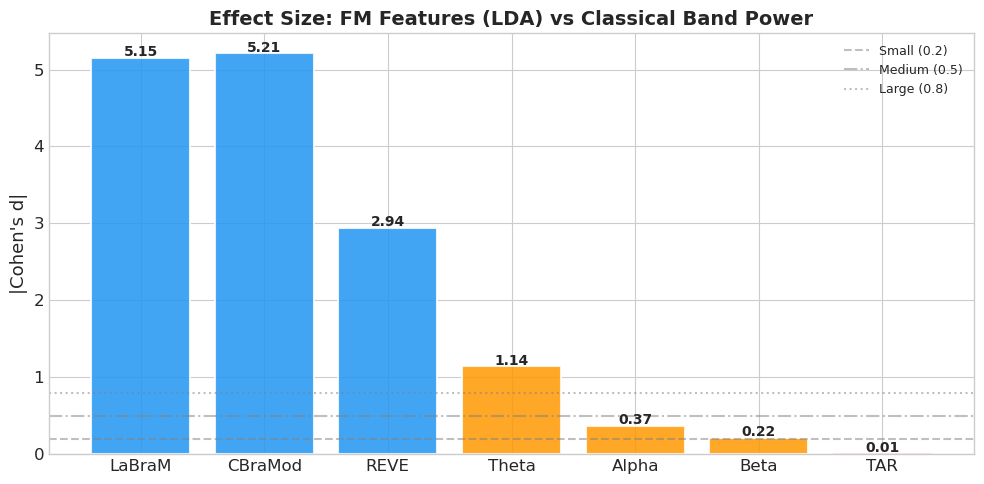

In [5]:
def cohens_d(a, b):
    """Cohen's d effect size (pooled SD)."""
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na-1)*a.std()**2 + (nb-1)*b.std()**2) / (na+nb-2))
    if pooled_std < 1e-10:
        return 0.0
    return (a.mean() - b.mean()) / pooled_std


# FM effect sizes via LDA projection
effect_sizes = {}

for fm_name, feats in fm_features.items():
    # Project to 1D via LDA (best linear discriminant for stress)
    lda = LinearDiscriminantAnalysis(n_components=1)
    proj = lda.fit_transform(feats, labels).ravel()
    d = abs(cohens_d(proj[labels == 0], proj[labels == 1]))
    effect_sizes[fm_name] = d
    print(f'{fm_name} (LDA proj): Cohen\'s d = {d:.3f}')

# Classical band power effect sizes
# Compute from cached EEG epochs directly
print('\n--- Computing classical band power features ---')

from scipy.signal import welch

bands = {'Theta': (4, 8), 'Alpha': (8, 13), 'Beta': (13, 30)}
sfreq = 200.0

# Load epoch cache and compute band powers per recording
band_powers = {band: [] for band in bands}

ds_zscore = StressEEGDataset(CSV_PATH, DATA_ROOT, norm='zscore', max_duration=MAX_DURATION)

for idx in range(len(ds_zscore)):
    rec = ds_zscore.records[idx]
    cache_path = os.path.join(ds_zscore.cache_dir, rec['cache_name'])
    epochs = torch.load(cache_path, weights_only=True).numpy()  # (M, C, T)
    
    # Average across epochs first, then compute PSD
    mean_epoch = epochs.mean(axis=0)  # (C, T)
    freqs, psd = welch(mean_epoch, fs=sfreq, nperseg=min(256, mean_epoch.shape[1]))
    
    for band_name, (flo, fhi) in bands.items():
        band_mask = (freqs >= flo) & (freqs < fhi)
        bp = psd[:, band_mask].mean(axis=1).mean()  # mean across channels and freq bins
        band_powers[band_name].append(bp)

for band_name in bands:
    bp = np.array(band_powers[band_name])
    d = abs(cohens_d(bp[labels == 0], bp[labels == 1]))
    effect_sizes[band_name] = d
    print(f'{band_name} band power: Cohen\'s d = {d:.3f}')

# Also compute Theta/Alpha Ratio (TAR)
tar = np.array(band_powers['Theta']) / (np.array(band_powers['Alpha']) + 1e-10)
d_tar = abs(cohens_d(tar[labels == 0], tar[labels == 1]))
effect_sizes['TAR'] = d_tar
print(f'Theta/Alpha Ratio: Cohen\'s d = {d_tar:.3f}')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names = list(effect_sizes.keys())
values = [effect_sizes[n] for n in names]
colors = ['#2196F3']*3 + ['#FF9800']*3 + ['#F44336']  # FM=blue, Band=orange, TAR=red

bars = ax.bar(names, values, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)

# Reference lines for effect size interpretation
ax.axhline(y=0.2, color='gray', linestyle='--', alpha=0.5, label='Small (0.2)')
ax.axhline(y=0.5, color='gray', linestyle='-.', alpha=0.5, label='Medium (0.5)')
ax.axhline(y=0.8, color='gray', linestyle=':', alpha=0.5, label='Large (0.8)')

# Value labels
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('|Cohen\'s d|', fontsize=13)
ax.set_title('Effect Size: FM Features (LDA) vs Classical Band Power',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, 'effect_size_comparison.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'\nSaved: {save_path}')
plt.show()

## 5. Within-Subject vs Between-Subject Similarity
How much does subject identity dominate the embedding space?

LaBraM:
  Within-subject sim:  0.9812 +/- 0.0141
  Between-subject sim: 0.9435 +/- 0.0299
  Subject gap: 0.0376
  Same-label sim (cross-subj): 0.9416
  Diff-label sim (cross-subj): 0.9468
  Label gap: -0.0051

CBraMod:
  Within-subject sim:  0.9985 +/- 0.0018
  Between-subject sim: 0.9961 +/- 0.0027
  Subject gap: 0.0023
  Same-label sim (cross-subj): 0.9958
  Diff-label sim (cross-subj): 0.9967
  Label gap: -0.0009

REVE:
  Within-subject sim:  0.9220 +/- 0.0799
  Between-subject sim: 0.8397 +/- 0.1305
  Subject gap: 0.0823
  Same-label sim (cross-subj): 0.8327
  Diff-label sim (cross-subj): 0.8515
  Label gap: -0.0187

Saved: results/fm_diagnosis/within_vs_between_subject.png


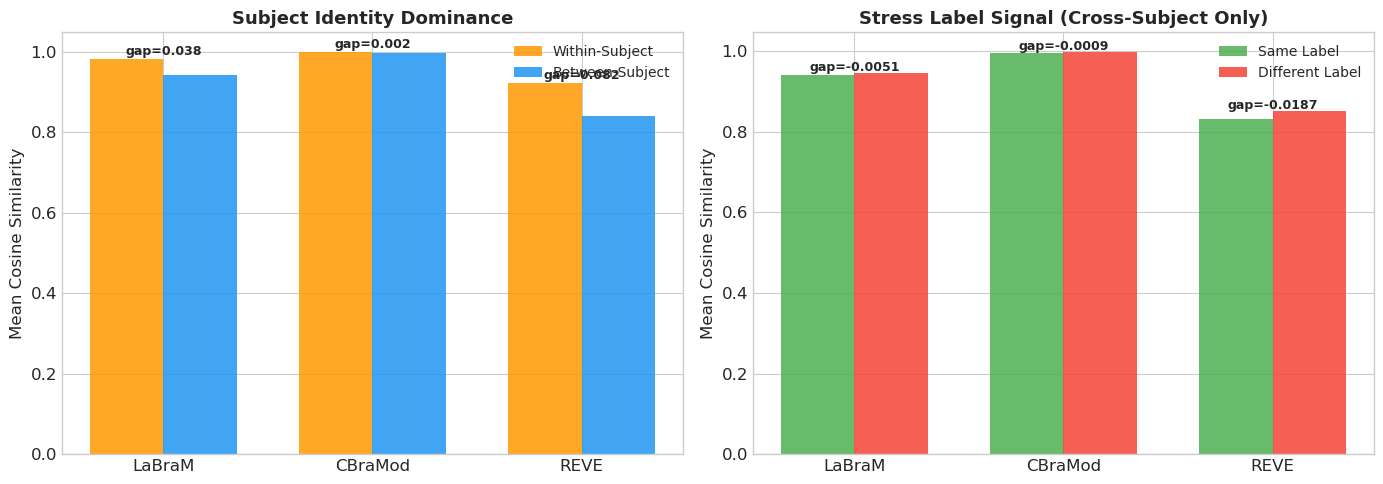

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_results = {}

for fm_name, feats in fm_features.items():
    sim_matrix = cosine_similarity(feats)  # (N, N)
    
    within_sims = []
    between_sims = []
    
    for i in range(len(feats)):
        for j in range(i+1, len(feats)):
            if patient_ids[i] == patient_ids[j]:
                within_sims.append(sim_matrix[i, j])
            else:
                between_sims.append(sim_matrix[i, j])
    
    within_sims = np.array(within_sims)
    between_sims = np.array(between_sims)
    
    # Also compute same-label vs diff-label (between subjects only)
    same_label_sims = []
    diff_label_sims = []
    for i in range(len(feats)):
        for j in range(i+1, len(feats)):
            if patient_ids[i] != patient_ids[j]:  # only between-subject pairs
                if labels[i] == labels[j]:
                    same_label_sims.append(sim_matrix[i, j])
                else:
                    diff_label_sims.append(sim_matrix[i, j])
    
    same_label_sims = np.array(same_label_sims)
    diff_label_sims = np.array(diff_label_sims)
    
    similarity_results[fm_name] = {
        'within_mean': within_sims.mean(),
        'within_std': within_sims.std(),
        'between_mean': between_sims.mean(),
        'between_std': between_sims.std(),
        'gap_subject': within_sims.mean() - between_sims.mean(),
        'same_label_mean': same_label_sims.mean(),
        'diff_label_mean': diff_label_sims.mean(),
        'gap_label': same_label_sims.mean() - diff_label_sims.mean(),
    }
    
    print(f'{fm_name}:')
    print(f'  Within-subject sim:  {within_sims.mean():.4f} +/- {within_sims.std():.4f}')
    print(f'  Between-subject sim: {between_sims.mean():.4f} +/- {between_sims.std():.4f}')
    print(f'  Subject gap: {similarity_results[fm_name]["gap_subject"]:.4f}')
    print(f'  Same-label sim (cross-subj): {same_label_sims.mean():.4f}')
    print(f'  Diff-label sim (cross-subj): {diff_label_sims.mean():.4f}')
    print(f'  Label gap: {similarity_results[fm_name]["gap_label"]:.4f}')
    print()

# Grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: within vs between subject
ax = axes[0]
fm_names = list(similarity_results.keys())
x = np.arange(len(fm_names))
width = 0.35

within_means = [similarity_results[n]['within_mean'] for n in fm_names]
between_means = [similarity_results[n]['between_mean'] for n in fm_names]

ax.bar(x - width/2, within_means, width, label='Within-Subject', color='#FF9800', alpha=0.85)
ax.bar(x + width/2, between_means, width, label='Between-Subject', color='#2196F3', alpha=0.85)
ax.set_ylabel('Mean Cosine Similarity', fontsize=12)
ax.set_title('Subject Identity Dominance', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(fm_names)
ax.legend(fontsize=10)

# Annotate gaps
for i, name in enumerate(fm_names):
    gap = similarity_results[name]['gap_subject']
    ax.annotate(f'gap={gap:.3f}', xy=(x[i], max(within_means[i], between_means[i]) + 0.01),
                ha='center', fontsize=9, fontweight='bold')

# Right: same-label vs diff-label (cross-subject only)
ax = axes[1]
same_means = [similarity_results[n]['same_label_mean'] for n in fm_names]
diff_means = [similarity_results[n]['diff_label_mean'] for n in fm_names]

ax.bar(x - width/2, same_means, width, label='Same Label', color='#4CAF50', alpha=0.85)
ax.bar(x + width/2, diff_means, width, label='Different Label', color='#F44336', alpha=0.85)
ax.set_ylabel('Mean Cosine Similarity', fontsize=12)
ax.set_title('Stress Label Signal (Cross-Subject Only)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(fm_names)
ax.legend(fontsize=10)

for i, name in enumerate(fm_names):
    gap = similarity_results[name]['gap_label']
    ax.annotate(f'gap={gap:.4f}', xy=(x[i], max(same_means[i], diff_means[i]) + 0.005),
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, 'within_vs_between_subject.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

## 6. Silhouette Analysis
Clustering quality when grouping by subject ID vs stress label.

LaBraM: silhouette(subject)=0.1616, silhouette(stress)=-0.0233
CBraMod: silhouette(subject)=-0.0076, silhouette(stress)=-0.1111
REVE: silhouette(subject)=-0.0475, silhouette(stress)=-0.0673

Saved: results/fm_diagnosis/silhouette_comparison.png


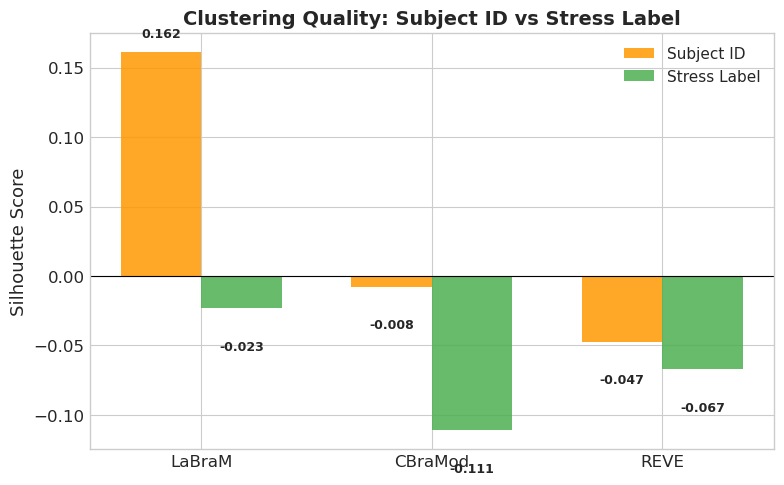

In [7]:
silhouette_results = {}

for fm_name, feats in fm_features.items():
    sil_subject = silhouette_score(feats, patient_ids, metric='cosine')
    sil_stress = silhouette_score(feats, labels, metric='cosine')
    
    silhouette_results[fm_name] = {
        'subject': sil_subject,
        'stress': sil_stress,
    }
    print(f'{fm_name}: silhouette(subject)={sil_subject:.4f}, silhouette(stress)={sil_stress:.4f}')

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
fm_names = list(silhouette_results.keys())
x = np.arange(len(fm_names))
width = 0.35

subj_vals = [silhouette_results[n]['subject'] for n in fm_names]
stress_vals = [silhouette_results[n]['stress'] for n in fm_names]

ax.bar(x - width/2, subj_vals, width, label='Subject ID', color='#FF9800', alpha=0.85)
ax.bar(x + width/2, stress_vals, width, label='Stress Label', color='#4CAF50', alpha=0.85)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Silhouette Score', fontsize=13)
ax.set_title('Clustering Quality: Subject ID vs Stress Label', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(fm_names, fontsize=12)
ax.legend(fontsize=11)

# Value labels
for i in range(len(fm_names)):
    for val, offset in [(subj_vals[i], -width/2), (stress_vals[i], width/2)]:
        yoff = 0.01 if val >= 0 else -0.03
        ax.text(x[i] + offset, val + yoff, f'{val:.3f}',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, 'silhouette_comparison.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'\nSaved: {save_path}')
plt.show()

## 7. Summary Table

In [8]:
# Build summary DataFrame
rows = []
for fm_name in fm_features.keys():
    rows.append({
        'Model': fm_name,
        'Embed Dim': fm_features[fm_name].shape[1],
        'eta2 Subject': f"{variance_results[fm_name]['eta2_subject_mean']:.4f}",
        'eta2 Stress': f"{variance_results[fm_name]['eta2_stress_mean']:.4f}",
        'Subject/Stress Ratio': f"{variance_results[fm_name]['ratio']:.1f}x",
        'Cohen d (LDA)': f"{effect_sizes[fm_name]:.3f}",
        'Silhouette Subject': f"{silhouette_results[fm_name]['subject']:.4f}",
        'Silhouette Stress': f"{silhouette_results[fm_name]['stress']:.4f}",
        'Within-Subj Sim': f"{similarity_results[fm_name]['within_mean']:.4f}",
        'Between-Subj Sim': f"{similarity_results[fm_name]['between_mean']:.4f}",
        'Subject Sim Gap': f"{similarity_results[fm_name]['gap_subject']:.4f}",
        'Label Sim Gap': f"{similarity_results[fm_name]['gap_label']:.4f}",
    })

# Add classical features row
for band_name in ['Theta', 'Alpha', 'Beta', 'TAR']:
    rows.append({
        'Model': f'Classical ({band_name})',
        'Embed Dim': '1 (scalar)',
        'eta2 Subject': '-',
        'eta2 Stress': '-',
        'Subject/Stress Ratio': '-',
        'Cohen d (LDA)': f"{effect_sizes.get(band_name, 0):.3f}",
        'Silhouette Subject': '-',
        'Silhouette Stress': '-',
        'Within-Subj Sim': '-',
        'Between-Subj Sim': '-',
        'Subject Sim Gap': '-',
        'Label Sim Gap': '-',
    })

summary_df = pd.DataFrame(rows)
display(summary_df)

save_path = os.path.join(SAVE_DIR, 'diagnosis_summary.csv')
summary_df.to_csv(save_path, index=False)
print(f'\nSaved: {save_path}')

# Key findings
print('\n' + '='*60)
print('KEY FINDINGS')
print('='*60)
for fm_name in fm_features.keys():
    r = variance_results[fm_name]
    print(f'\n{fm_name}:')
    print(f'  Subject ID explains {r["eta2_subject_mean"]*100:.1f}% of feature variance')
    print(f'  Stress label explains {r["eta2_stress_mean"]*100:.1f}% of feature variance')
    print(f'  Subject dominance: {r["ratio"]:.0f}x more variance from subject than stress')

,Model,Embed Dim,eta2 Subject,eta2 Stress,Subject/Stress Ratio,Cohen d (LDA),Silhouette Subject,Silhouette Stress,Within-Subj Sim,Between-Subj Sim,Subject Sim Gap,Label Sim Gap
0,LaBraM,200,0.6803,0.0201,33.9x,5.150,0.1616,-0.0233,0.9812,0.9435,0.0376,-0.0051
1,CBraMod,200,0.6258,0.0174,35.9x,5.210,-0.0076,-0.1111,0.9985,0.9961,0.0023,-0.0009
2,REVE,512,0.5462,0.0149,36.6x,2.939,-0.0475,-0.0673,0.9220,0.8397,0.0823,-0.0187
3,Classical (Theta),1 (scalar),-,-,-,1.144,-,-,-,-,-,-
4,Classical (Alpha),1 (scalar),-,-,-,0.371,-,-,-,-,-,-
5,Classical (Beta),1 (scalar),-,-,-,0.216,-,-,-,-,-,-
6,Classical (TAR),1 (scalar),-,-,-,0.013,-,-,-,-,-,-



Saved: results/fm_diagnosis/diagnosis_summary.csv

KEY FINDINGS

LaBraM:
  Subject ID explains 68.0% of feature variance
  Stress label explains 2.0% of feature variance
  Subject dominance: 34x more variance from subject than stress

CBraMod:
  Subject ID explains 62.6% of feature variance
  Stress label explains 1.7% of feature variance
  Subject dominance: 36x more variance from subject than stress

REVE:
  Subject ID explains 54.6% of feature variance
  Stress label explains 1.5% of feature variance
  Subject dominance: 37x more variance from subject than stress
